# Dataset-Driven Inspire RH56 Static Hand Mapping 

**Overview**

| Phase | Description |
|-------|-------------|
| 0 | Setup — install/import dependencies |
| 1 | Download internet dataset (Rock-Paper-Scissors) |
| 2 | Build/train gesture classifier |
| 3 | Map gesture class → Inspire RH56 DOF targets |
| 4 | Replay predictions to hardware (or mock mode) |
| 5 | Save / reload trained pipeline |

DOF order for all robot position arrays: `[little, ring, middle, index, thumb_bend, thumb_rotation]`


## Phase 0 — Setup

In [1]:
%pip install -q torch torchvision numpy matplotlib pymodbus pyserial pillow requests tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import zipfile
import random
import requests
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from pymodbus.client import ModbusSerialClient
import gc
import serial

# DOF Constants
DOF_NAMES = ["Little", "Ring", "Middle", "Index", "Thumb Bend", "Thumb Rot"]
N_DOFS = 6
POS_MIN, POS_MAX = 0, 1000

# RH56 series modbus USB-CH340 defaults 
DEFAULT_PORT = "/dev/ttyUSB0"
DEFAULT_BAUD = 115200
DEVICE_ID    = 1
REG_ANGLE_SET = 1486
REG_ANGLE_ACT = 1546
REG_FORCE_SET = 1498
REG_SPEED_SET = 1522

# Path defaults
DATA_DIR   = Path("rps_dataset")
MODEL_FILE = Path("gesture_classifier.pt")

# Training defaults
IMAGE_SIZE = 96
BATCH_SIZE = 64
EPOCHS     = 6
LR         = 1e-3

device = torch.device("cpu")
print(f"Using device: {device}")

/home/katelyn/research-inspire_hand_mirroring/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## Phase 1 — Download Dataset from the Internet

We use the public **Rock-Paper-Scissors** image dataset and train a gesture classifier.
Dataset source: TensorFlow public storage.


In [3]:
RPS_URL = "https://storage.googleapis.com/download.tensorflow.org/data/rps.zip"


def download_file(url: str, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        print(f"Already downloaded: {dst}")
        return

    print(f"Downloading {url} -> {dst}")
    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(dst, "wb") as f, tqdm(total=total, unit="B", unit_scale=True) as pbar:
            for chunk in r.iter_content(chunk_size=1024 * 64):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))


def extract_zip(zip_path: Path, out_dir: Path):
    if out_dir.exists() and any(out_dir.iterdir()):
        print(f"Dataset already extracted at: {out_dir}")
        return
    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(out_dir)
    print(f"Extracted to: {out_dir}")


zip_path = DATA_DIR / "rps.zip"
extract_dir = DATA_DIR / "raw"

download_file(RPS_URL, zip_path)
extract_zip(zip_path, extract_dir)

root = extract_dir / "rps"
classes = sorted([p.name for p in root.iterdir() if p.is_dir()])
print("Classes:", classes)
for cls in classes:
    n = len(list((root / cls).glob("*.png")))
    print(f"  {cls:<10} {n:>5} images")


Already downloaded: rps_dataset/rps.zip
Dataset already extracted at: rps_dataset/raw
Classes: ['paper', 'rock', 'scissors']
  paper        840 images
  rock         840 images
  scissors     840 images


class_names: ['paper', 'rock', 'scissors']
train=2016  val=504


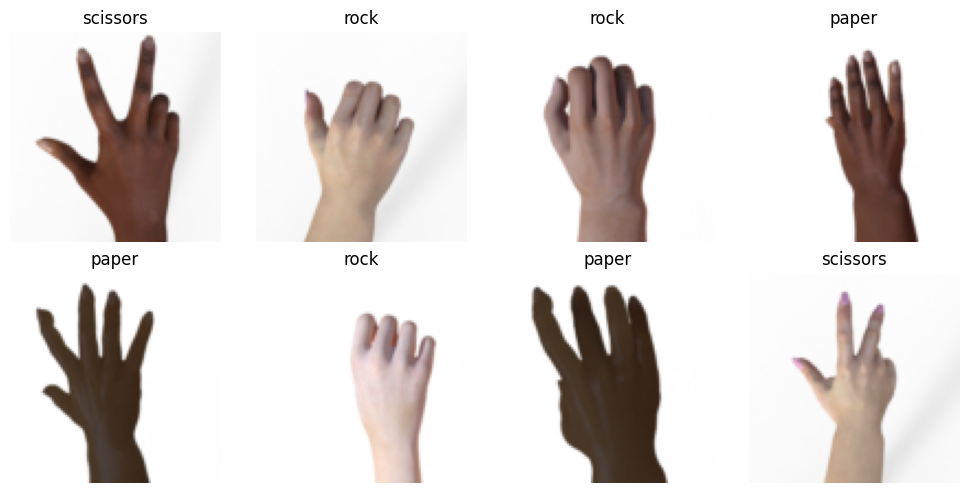

In [4]:
tfm = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(root=str(root), transform=tfm)
class_names = dataset.classes
num_classes = len(class_names)
print("class_names:", class_names)

# Deterministic split
rng = torch.Generator().manual_seed(42)
n_total = len(dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train
train_ds, val_ds = torch.utils.data.random_split(dataset, [n_train, n_val], generator=rng)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"train={len(train_ds)}  val={len(val_ds)}")

# Preview a few samples
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax in axes.ravel():
    i = random.randint(0, len(dataset) - 1)
    img, y = dataset[i]
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    ax.set_title(class_names[y])
    ax.axis("off")
plt.tight_layout()
plt.show()


## Phase 2 — Train Gesture Classifier

In [5]:
class GestureCNN(nn.Module):
    def __init__(self, n_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (IMAGE_SIZE // 8) * (IMAGE_SIZE // 8), 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return total_loss / max(total, 1), correct / max(total, 1)


def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    criterion = nn.CrossEntropyLoss()
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for ep in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        seen = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optim.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optim.step()
            running_loss += loss.item() * x.size(0)
            seen += y.size(0)

        train_loss = running_loss / max(seen, 1)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"Epoch {ep:>2}/{epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.3f}")

    return history


/home/katelyn/research-inspire_hand_mirroring/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12050). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch  1/6  train_loss=0.9859  val_loss=0.6841  val_acc=0.756
Epoch  2/6  train_loss=0.3764  val_loss=0.2546  val_acc=0.948
Epoch  3/6  train_loss=0.1259  val_loss=0.0741  val_acc=0.976
Epoch  4/6  train_loss=0.0378  val_loss=0.0513  val_acc=0.980
Epoch  5/6  train_loss=0.0231  val_loss=0.0253  val_acc=0.986
Epoch  6/6  train_loss=0.0128  val_loss=0.0224  val_acc=0.990


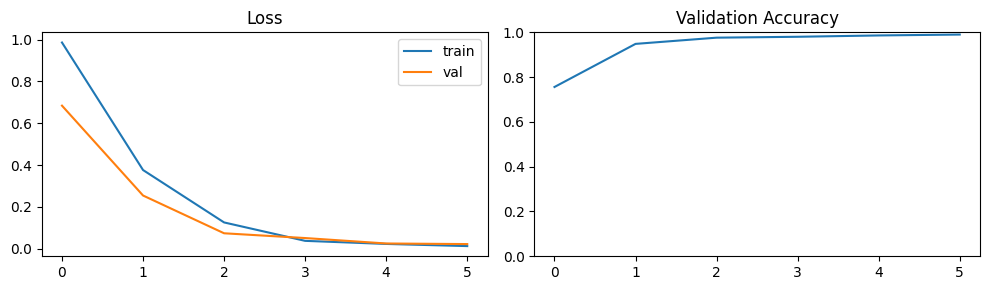

In [6]:
model = GestureCNN(num_classes).to(device)
history = train_model(model, train_loader, val_loader)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()
axes[1].plot(history["val_acc"])
axes[1].set_title("Validation Accuracy")
axes[1].set_ylim(0.0, 1.0)
plt.tight_layout()
plt.show()


## Phase 3 — Map Gesture Class to RH56 DOF Targets

Classifier output (`rock`, `paper`, `scissors`) is converted to fixed RH56 target vectors.


In [7]:
GESTURE_TO_DOF = {
    "paper":    [1000, 1000, 1000, 1000, 1000, 500],  # open hand
    "rock":     [0, 0, 0, 0, 150, 900],               # closed fist
    "scissors": [0, 0, 1000, 1000, 300, 700],         # index + middle open
}


def predict_gesture_logits(model, image_tensor: torch.Tensor):
    model.eval()
    with torch.no_grad():
        x = image_tensor.unsqueeze(0).to(device)
        logits = model(x).squeeze(0).cpu()
    return logits


def predict_gesture_name(model, image_tensor: torch.Tensor):
    logits = predict_gesture_logits(model, image_tensor)
    idx = int(torch.argmax(logits).item())
    return class_names[idx], idx


def predict_dof_from_image(model, image_tensor: torch.Tensor):
    gesture, idx = predict_gesture_name(model, image_tensor)
    if gesture not in GESTURE_TO_DOF:
        raise KeyError(f"No DOF mapping configured for gesture '{gesture}'")
    return gesture, np.array(GESTURE_TO_DOF[gesture], dtype=np.float32)


true=scissors  pred=scissors  dof=[0, 0, 1000, 1000, 300, 700]
true=paper     pred=paper     dof=[1000, 1000, 1000, 1000, 1000, 500]
true=paper     pred=paper     dof=[1000, 1000, 1000, 1000, 1000, 500]
true=scissors  pred=scissors  dof=[0, 0, 1000, 1000, 300, 700]
true=rock      pred=rock      dof=[0, 0, 0, 0, 150, 900]
true=rock      pred=rock      dof=[0, 0, 0, 0, 150, 900]


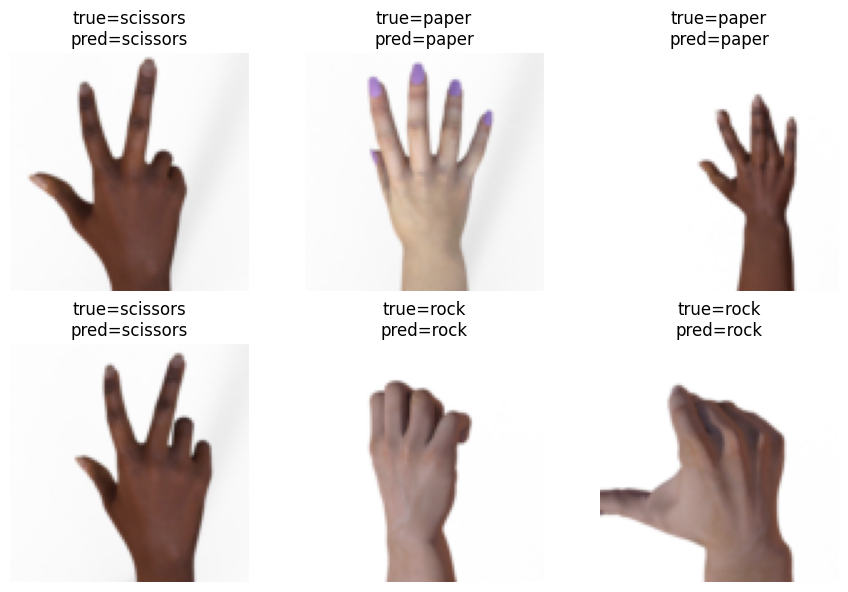

In [8]:
# Quick sanity-check on random validation samples
n_show = 6
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax in axes.ravel():
    i = random.randint(0, len(val_ds) - 1)
    img, y = val_ds[i]
    pred_name, pred_dof = predict_dof_from_image(model, img)
    true_name = class_names[int(y)]

    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    ax.set_title(f"true={true_name}\npred={pred_name}")
    ax.axis("off")

    print(f"true={true_name:<8}  pred={pred_name:<8}  dof={pred_dof.astype(int).tolist()}")

plt.tight_layout()
plt.show()


## Phase 4 — Inspire Hand Interface

In [9]:
def release_stale_serial_handles(port: str):
    closed = 0
    for obj in gc.get_objects():
        try:
            if isinstance(obj, serial.Serial):
                if getattr(obj, "port", None) == port and obj.is_open:
                    obj.close()
                    closed += 1
        except Exception:
            pass
    if closed:
        print(f"[InspireHand] Closed {closed} stale serial handle(s) on {port}")


class InspireHand:

    def __init__(self, port: str = DEFAULT_PORT, baud: int = DEFAULT_BAUD, device_id: int = DEVICE_ID):
        self.port = port
        self.baud = baud
        self.device_id = device_id
        self._client = None
        self._mock = False

    def connect(self) -> bool:
        # Ensure any previous handle is closed before re-opening the same port.
        self.disconnect()
        release_stale_serial_handles(self.port)
        self._mock = False
        self._client = ModbusSerialClient(
            port=self.port,
            baudrate=self.baud,
            bytesize=8,
            parity="N",
            stopbits=1,
            timeout=1,
        )
        ok = self._client.connect()
        if not ok:
            print(f"[InspireHand] WARNING: could not connect on {self.port}. Running in mock mode.")
            self._mock = True
        else:
            print(f"[InspireHand] Connected on {self.port} @ {self.baud} baud")
        return ok

    def disconnect(self):
        if self._client is not None:
            try:
                self._client.close()
            except Exception:
                pass
        self._client = None

    def set_angles(self, positions) -> bool:
        if len(positions) != N_DOFS:
            raise ValueError(f"Expected {N_DOFS} positions, got {len(positions)}")
        clamped = [int(np.clip(v, POS_MIN, POS_MAX)) for v in positions]
        if self._mock:
            return True
        result = self._client.write_registers(
            address=REG_ANGLE_SET, values=clamped, device_id=self.device_id
        )
        return not result.isError()

    def get_angles(self):
        if self._mock:
            return [500] * N_DOFS
        result = self._client.read_holding_registers(
            address=REG_ANGLE_ACT, count=N_DOFS, device_id=self.device_id
        )
        if result.isError():
            return [0] * N_DOFS
        return list(result.registers)

    def __enter__(self):
        self.connect()
        return self

    def __exit__(self, *_):
        self.disconnect()

In [10]:
# Quick sanity-check on hardware connection
hand_test = InspireHand(port=DEFAULT_PORT)

try:
    hand_test.connect()
    if not hand_test._mock:
        print("Current angles:", hand_test.get_angles())
        hand_test.set_angles([500] * N_DOFS)
        time.sleep(0.5)
        print("After set:", hand_test.get_angles())
    else:
        print("Mock mode active — hardware test skipped.")
finally:
    hand_test.disconnect()
    print("[InspireHand] Port released")


<frozen abc>:119: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead


[InspireHand] Connected on /dev/ttyUSB0 @ 115200 baud
Current angles: [928, 856, 977, 880, 787, 894]
After set: [503, 505, 506, 501, 505, 488]
[InspireHand] Port released


In [11]:
def replay_dataset_control(model, dataset_split, n_steps: int = 40,
                           hand: "InspireHand | None" = None,
                           delay_s: float = 0.15):

    model.eval()
    for step in range(1, n_steps + 1):
        i = random.randint(0, len(dataset_split) - 1)
        img, y = dataset_split[i]
        true_name = class_names[int(y)]
        pred_name, dof = predict_dof_from_image(model, img)

        if hand is not None:
            hand.set_angles(dof.tolist())

        print(f"step {step:>3}: true={true_name:<8} pred={pred_name:<8} dof={dof.astype(int).tolist()}")
        time.sleep(delay_s)


## Phase 5 — Replay Predicted Commands


In [14]:
with InspireHand(port=DEFAULT_PORT) as hand:
    replay_dataset_control(model, val_ds, n_steps=20, hand=hand, delay_s=1.0)


[InspireHand] Connected on /dev/ttyUSB0 @ 115200 baud
step   1: true=rock     pred=rock     dof=[0, 0, 0, 0, 150, 900]
step   2: true=rock     pred=rock     dof=[0, 0, 0, 0, 150, 900]
step   3: true=paper    pred=paper    dof=[1000, 1000, 1000, 1000, 1000, 500]
step   4: true=scissors pred=scissors dof=[0, 0, 1000, 1000, 300, 700]
step   5: true=scissors pred=scissors dof=[0, 0, 1000, 1000, 300, 700]
step   6: true=rock     pred=rock     dof=[0, 0, 0, 0, 150, 900]
step   7: true=scissors pred=scissors dof=[0, 0, 1000, 1000, 300, 700]
step   8: true=paper    pred=paper    dof=[1000, 1000, 1000, 1000, 1000, 500]
step   9: true=scissors pred=scissors dof=[0, 0, 1000, 1000, 300, 700]
step  10: true=rock     pred=rock     dof=[0, 0, 0, 0, 150, 900]
step  11: true=rock     pred=rock     dof=[0, 0, 0, 0, 150, 900]
step  12: true=rock     pred=rock     dof=[0, 0, 0, 0, 150, 900]
step  13: true=rock     pred=rock     dof=[0, 0, 0, 0, 150, 900]
step  14: true=rock     pred=rock     dof=[0, 0, 0,

## Phase 6 — Persistence

In [13]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "class_names": class_names,
    "gesture_to_dof": GESTURE_TO_DOF,
    "image_size": IMAGE_SIZE,
}
torch.save(checkpoint, MODEL_FILE)
print(f"Saved checkpoint -> {MODEL_FILE}")


def load_pipeline(model_path=MODEL_FILE):
    ckpt = torch.load(model_path, map_location=device)
    m = GestureCNN(n_classes=len(ckpt["class_names"])).to(device)
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    print(f"Loaded model from {model_path}")
    print("Classes:", ckpt["class_names"])
    return m, ckpt["class_names"], ckpt["gesture_to_dof"]


loaded_model, loaded_classes, loaded_map = load_pipeline()


Saved checkpoint -> gesture_classifier.pt
Loaded model from gesture_classifier.pt
Classes: ['paper', 'rock', 'scissors']
